# Notebook 00 — Dataset Merging & Exploration

## Diabetic Retinopathy Classification Project

**Purpose:** Merge three public fundus-image datasets (APTOS 2019, IDRiD, Messidor-2) into a single unified CSV, perform hash-based deduplication, and conduct exploratory data analysis (EDA).

**Outputs saved:**
| Artifact | Path |
|---|---|
| Unified label CSV | `merged_labels.csv` |
| EDA figures | `figures/` directory |

---

In [1]:
# ============================================================
# 1. Imports & Configuration
# ============================================================
import os
import sys
import hashlib
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ── Reproducibility ──
SEED = 42
np.random.seed(SEED)

# ── Project configuration ──
CONFIG = {
    "seed": SEED,
    # Root directory that contains the three dataset folders
    "data_root": ".",
    # Output paths (relative to data_root)
    "output_csv": "merged_labels.csv",
    "figures_dir": "figures",
    # Dataset-specific sub-paths
    "aptos": {
        "images_dir": "aptos2019-blindness-detection/train_images",
        "labels_csv": "aptos2019-blindness-detection/train.csv",
    },
    "idrid": {
        "train_images": "IDRiD/Train/images",
        "train_csv": "IDRiD/Train/annotations.csv",
        "test_images": "IDRiD/Test/images",
        "test_csv": "IDRiD/Test/annotations.csv",
    },
    "messidor2": {
        "images_dir": "messidor-2/messidor-2/messidor-2/preprocess",
        "labels_csv": "messidor-2/messidor_data.csv",
    },
}

ROOT = Path(CONFIG["data_root"])
FIG_DIR = ROOT / CONFIG["figures_dir"]
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data root  : {ROOT}")
print(f"Figures dir: {FIG_DIR}")
print("Configuration loaded ✓")


Data root  : .
Figures dir: figures
Configuration loaded ✓


## 2. Helper Functions

In [2]:
# ============================================================
# 2. Helper Functions
# ============================================================

def compute_image_hash(file_path: str, algorithm: str = "md5") -> Optional[str]:
    """Compute the MD5 (or SHA-256) hash of an image file for deduplication.

    Args:
        file_path: Absolute path to the image file.
        algorithm: Hash algorithm — 'md5' or 'sha256'.

    Returns:
        Hex-digest string, or None if the file cannot be read.
    """
    try:
        h = hashlib.new(algorithm)
        with open(file_path, "rb") as f:
            for chunk in iter(lambda: f.read(8192), b""):
                h.update(chunk)
        return h.hexdigest()
    except Exception as e:
        print(f"  [WARN] Could not hash {file_path}: {e}")
        return None


def get_image_dimensions(file_path: str) -> Tuple[int, int, int]:
    """Return (height, width, channels) of an image.

    Args:
        file_path: Absolute path to the image.

    Returns:
        Tuple of (height, width, channels). Returns (0, 0, 0) on failure.
    """
    try:
        img = cv2.imread(file_path)
        if img is not None:
            return img.shape  # (H, W, C)
    except Exception:
        pass
    return (0, 0, 0)


def grade_label_map() -> Dict[int, str]:
    """Return human-readable names for DR severity grades."""
    return {
        0: "No DR",
        1: "Mild NPDR",
        2: "Moderate NPDR",
        3: "Severe NPDR",
        4: "Proliferative DR",
    }


print("Helper functions defined ✓")


Helper functions defined ✓


## 3. Load Individual Datasets

### 3.1 APTOS 2019 Blindness Detection
- **Source:** Kaggle competition (2019)
- **Images:** ~3 662 fundus photographs
- **Labels:** `diagnosis` column with grades 0–4 matching the International Clinical DR Severity Scale directly.

In [3]:
# ============================================================
# 3.1 Load APTOS 2019
# ============================================================
aptos_csv = ROOT / CONFIG["aptos"]["labels_csv"]
aptos_img_dir = ROOT / CONFIG["aptos"]["images_dir"]

df_aptos = pd.read_csv(aptos_csv)
print(f"APTOS CSV rows: {len(df_aptos)}")
print(f"Columns: {list(df_aptos.columns)}")
print(f"Grade distribution:\n{df_aptos['diagnosis'].value_counts().sort_index()}\n")

# Build records
aptos_records: List[dict] = []
missing = 0
for _, row in tqdm(df_aptos.iterrows(), total=len(df_aptos), desc="APTOS"):
    img_name = f"{row['id_code']}.png"
    img_path = ROOT / CONFIG["aptos"]["images_dir"] / img_name
    if not img_path.exists():
        missing += 1
        continue
    aptos_records.append({
        "image_id": f"aptos_{row['id_code']}",
        "original_dataset": "aptos2019",
        "original_label": int(row["diagnosis"]),
        "dr_grade": int(row["diagnosis"]),
        "file_path": str(img_path),
    })

print(f"\nAPTOS — loaded {len(aptos_records)} images, {missing} missing files")


APTOS CSV rows: 3662
Columns: ['id_code', 'diagnosis']
Grade distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64



APTOS:   0%|          | 0/3662 [00:00<?, ?it/s]

APTOS:  15%|█▍        | 542/3662 [00:00<00:00, 5411.99it/s]

APTOS:  30%|██▉       | 1092/3662 [00:00<00:00, 5458.82it/s]

APTOS:  45%|████▍     | 1638/3662 [00:00<00:00, 5439.19it/s]

APTOS:  60%|█████▉    | 2182/3662 [00:00<00:00, 5347.39it/s]

APTOS:  74%|███████▍  | 2723/3662 [00:00<00:00, 5367.49it/s]

APTOS:  89%|████████▉ | 3262/3662 [00:00<00:00, 5062.47it/s]

APTOS: 100%|██████████| 3662/3662 [00:00<00:00, 5164.07it/s]


APTOS — loaded 3662 images, 0 missing files


### 3.2 IDRiD (Indian Diabetic Retinopathy Image Dataset)
- **Source:** IEEE DataPort
- **Images:** Train set + Test set (~1 548 total)
- **Labels:** `Retinopathy grade` column (0–4)
- **Note:** Train and test splits share the same filename numbering scheme (IDRiD_0001.jpg, …). We prefix with `idrid_train_` and `idrid_test_` to avoid collisions.

In [4]:
# ============================================================
# 3.2 Load IDRiD
# ============================================================
idrid_records: List[dict] = []
missing_idrid = 0

for split_name, img_key, csv_key in [
    ("train", "train_images", "train_csv"),
    ("test",  "test_images",  "test_csv"),
]:
    csv_path = ROOT / CONFIG["idrid"][csv_key]
    img_dir  = ROOT / CONFIG["idrid"][img_key]
    df = pd.read_csv(csv_path)
    print(f"IDRiD {split_name} — CSV rows: {len(df)}, columns: {list(df.columns)}")

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"IDRiD-{split_name}"):
        img_name = row["Image name"].strip()
        img_path = ROOT / CONFIG["idrid"][img_key] / img_name
        if not img_path.exists():
            missing_idrid += 1
            continue
        grade = int(row["Retinopathy grade"])
        # Prefix to avoid train/test filename collision
        stem = Path(img_name).stem
        idrid_records.append({
            "image_id": f"idrid_{split_name}_{stem}",
            "original_dataset": "idrid",
            "original_label": grade,
            "dr_grade": grade,
            "file_path": str(img_path),
        })

print(f"\nIDRiD — loaded {len(idrid_records)} images, {missing_idrid} missing files")


IDRiD train — CSV rows: 1239, columns: ['Image name', 'Retinopathy grade', 'Risk of macular edema', 'class', 'caption']


IDRiD-train:   0%|          | 0/1239 [00:00<?, ?it/s]

IDRiD-train:  67%|██████▋   | 834/1239 [00:00<00:00, 8338.99it/s]

IDRiD-train: 100%|██████████| 1239/1239 [00:00<00:00, 7473.89it/s]

IDRiD test — CSV rows: 309, columns: ['Image name', 'Retinopathy grade', 'Risk of macular edema', 'class', 'caption']


IDRiD-test:   0%|          | 0/309 [00:00<?, ?it/s]

IDRiD-test: 100%|██████████| 309/309 [00:00<00:00, 7219.51it/s]


IDRiD — loaded 1548 images, 0 missing files


### 3.3 Messidor-2
- **Source:** ADCIS / LaTIM
- **Images:** Preprocessed PNG files
- **Labels:** `diagnosis` column in the CSV already mapped to 0–4 scale

**Messidor-2 Grade Mapping Documentation:**

The original Messidor-2 annotation system uses a 0–3 retinopathy grade (R0–R3). Many publicly available versions (including the Kaggle re-release) have already been re-mapped to the 5-class International Clinical DR Severity Scale:

| Original Messidor Grade | Mapped DR Grade | Severity |
|---|---|---|
| R0 (No DR) | 0 | No DR |
| R1 (Mild NPDR) | 1 | Mild NPDR |
| R1/R2 (Moderate NPDR) | 2 | Moderate NPDR |
| R2 (Severe NPDR) | 3 | Severe NPDR |
| R3 (Proliferative DR) | 4 | Proliferative DR |

The CSV we have uses `diagnosis` values 0–4, consistent with APTOS and IDRiD, so **no additional mapping is needed** — we use them directly.

In [5]:
# ============================================================
# 3.3 Load Messidor-2
# ============================================================
mess_csv = ROOT / CONFIG["messidor2"]["labels_csv"]
mess_img_dir = ROOT / CONFIG["messidor2"]["images_dir"]

df_mess = pd.read_csv(mess_csv)
print(f"Messidor-2 CSV rows: {len(df_mess)}")
print(f"Columns: {list(df_mess.columns)}")
print(f"Grade distribution:\n{df_mess['diagnosis'].value_counts().sort_index()}\n")

mess_records: List[dict] = []
missing_mess = 0

for _, row in tqdm(df_mess.iterrows(), total=len(df_mess), desc="Messidor-2"):
    img_name = row["id_code"]
    # Images are PNGs in the preprocess folder
    img_path = ROOT / CONFIG["messidor2"]["images_dir"] / img_name
    if not img_path.exists():
        missing_mess += 1
        continue
    grade = int(row["diagnosis"])
    stem = Path(img_name).stem
    mess_records.append({
        "image_id": f"messidor2_{stem}",
        "original_dataset": "messidor2",
        "original_label": grade,
        "dr_grade": grade,
        "file_path": str(img_path),
    })

print(f"\nMessidor-2 — loaded {len(mess_records)} images, {missing_mess} missing files")
print(f"  (Missing images are expected: CSV has {len(df_mess)} entries but only "
      f"{len(list(Path(mess_img_dir).glob('*.png')))} preprocessed PNGs exist)")


Messidor-2 CSV rows: 1744
Columns: ['id_code', 'diagnosis', 'adjudicated_dme', 'adjudicated_gradable']
Grade distribution:
diagnosis
0    1017
1     270
2     347
3      75
4      35
Name: count, dtype: int64



Messidor-2:   0%|          | 0/1744 [00:00<?, ?it/s]

Messidor-2:  33%|███▎      | 574/1744 [00:00<00:00, 5731.40it/s]

Messidor-2:  67%|██████▋   | 1166/1744 [00:00<00:00, 5838.60it/s]

Messidor-2: 100%|██████████| 1744/1744 [00:00<00:00, 5874.57it/s]


Messidor-2 — loaded 1744 images, 0 missing files
  (Missing images are expected: CSV has 1744 entries but only 1057 preprocessed PNGs exist)


## 4. Merge Into Unified DataFrame

In [6]:
# ============================================================
# 4. Merge into a single DataFrame
# ============================================================
all_records = aptos_records + idrid_records + mess_records
df_merged = pd.DataFrame(all_records)

# Add binary label: 0 = No DR, 1 = DR present
df_merged["binary_label"] = (df_merged["dr_grade"] > 0).astype(int)

print(f"Total merged records: {len(df_merged)}")
print(f"\nDataset breakdown:")
print(df_merged["original_dataset"].value_counts().to_string())
print(f"\nDR grade distribution (merged):")
print(df_merged["dr_grade"].value_counts().sort_index().to_string())
print(f"\nBinary label distribution:")
print(df_merged["binary_label"].value_counts().sort_index().to_string())
print(f"\nColumns: {list(df_merged.columns)}")
df_merged.head(10)


Total merged records: 6954

Dataset breakdown:
original_dataset
aptos2019    3662
messidor2    1744
idrid        1548

DR grade distribution (merged):
dr_grade
0    3326
1     715
2    1850
3     547
4     516

Binary label distribution:
binary_label
0    3326
1    3628

Columns: ['image_id', 'original_dataset', 'original_label', 'dr_grade', 'file_path', 'binary_label']


,image_id,original_dataset,original_label,dr_grade,file_path,binary_label
0,aptos_000c1434d8d7,aptos2019,2,2,/sessions/vibrant-gifted-euler/mnt/DrMulti_Bin...,1
1,aptos_001639a390f0,aptos2019,4,4,/sessions/vibrant-gifted-euler/mnt/DrMulti_Bin...,1
2,aptos_0024cdab0c1e,aptos2019,1,1,/sessions/vibrant-gifted-euler/mnt/DrMulti_Bin...,1
3,aptos_002c21358ce6,aptos2019,0,0,/sessions/vibrant-gifted-euler/mnt/DrMulti_Bin...,0
4,aptos_005b95c28852,aptos2019,0,0,/sessions/vibrant-gifted-euler/mnt/DrMulti_Bin...,0
5,aptos_0083ee8054ee,aptos2019,4,4,/sessions/vibrant-gifted-euler/mnt/DrMulti_Bin...,1
6,aptos_0097f532ac9f,aptos2019,0,0,/sessions/vibrant-gifted-euler/mnt/DrMulti_Bin...,0
7,aptos_00a8624548a9,aptos2019,2,2,/sessions/vibrant-gifted-euler/mnt/DrMulti_Bin...,1
8,aptos_00b74780d31d,aptos2019,2,2,/sessions/vibrant-gifted-euler/mnt/DrMulti_Bin...,1
9,aptos_00cb6555d108,aptos2019,1,1,/sessions/vibrant-gifted-euler/mnt/DrMulti_Bin...,1


## 5. Hash-Based Deduplication

We compute an MD5 hash for every image and check for exact duplicates **across** datasets. Images that are byte-identical (same MD5) are flagged, and only the first occurrence is kept.

In [7]:
# ============================================================
# 5. Hash-based deduplication
# ============================================================
print("Computing image hashes (this may take a few minutes)...")
hashes = []
for fp in tqdm(df_merged["file_path"].values, desc="Hashing"):
    hashes.append(compute_image_hash(str(ROOT / fp)))

df_merged["image_hash"] = hashes

# Check for None hashes (unreadable files)
null_hashes = df_merged["image_hash"].isna().sum()
if null_hashes:
    print(f"WARNING: {null_hashes} images could not be hashed — dropping them.")
    df_merged = df_merged.dropna(subset=["image_hash"]).reset_index(drop=True)

# Find duplicates
dup_mask = df_merged.duplicated(subset=["image_hash"], keep="first")
n_dups = dup_mask.sum()
print(f"\nDuplicate images found: {n_dups}")

if n_dups > 0:
    dups = df_merged[dup_mask]
    print("\nDuplicate entries (showing first 20):")
    print(dups[["image_id", "original_dataset", "dr_grade", "image_hash"]].head(20).to_string())

    # Which dataset pairs have duplicates?
    for h in dups["image_hash"].unique()[:10]:
        group = df_merged[df_merged["image_hash"] == h]
        datasets = group["original_dataset"].unique()
        if len(datasets) > 1:
            print(f"  Cross-dataset duplicate: hash={h[:12]}… in {list(datasets)}")

    # Keep first occurrence only
    df_merged = df_merged[~dup_mask].reset_index(drop=True)
    print(f"\nAfter deduplication: {len(df_merged)} images remain")
else:
    print("No duplicate images detected across datasets ✓")

# Final counts
print(f"\n{'='*60}")
print(f"FINAL MERGED DATASET: {len(df_merged)} unique images")
print(f"{'='*60}")


Computing image hashes (this may take a few minutes)...


Hashing:   0%|          | 0/6954 [00:00<?, ?it/s]

Hashing:   0%|          | 12/6954 [00:00<00:59, 116.09it/s]

Hashing:   0%|          | 27/6954 [00:00<00:51, 135.53it/s]

Hashing:   1%|          | 41/6954 [00:00<00:54, 126.21it/s]

...

Hashing:  94%|█████████▍| 6553/6954 [00:32<00:00, 1047.58it/s]

Hashing:  97%|█████████▋| 6737/6954 [00:33<00:00, 1282.17it/s]

Hashing:  99%|█████████▉| 6912/6954 [00:33<00:00, 1421.14it/s]

Hashing: 100%|██████████| 6954/6954 [00:33<00:00, 209.67it/s] 


Duplicate images found: 150

Duplicate entries (showing first 20):
                image_id original_dataset  dr_grade                        image_hash
352   aptos_19e350c7c83c        aptos2019         1  f531664675320df675bab2274044de4f
425   aptos_1e143fa3de57        aptos2019         2  c76f749a820f01b47be98198f039ae19
439   aptos_1f07dae3cadb        aptos2019         2  028d27ff645aaeb21688586fbb0e9299
613   aptos_2b21d293fdf2        aptos2019         2  fc9975c1046cd6401c1900b351fc41ea
627   aptos_2c2aa057afc5        aptos2019         2  7c503683d5df9841616568d658e8036c
679   aptos_3044022c6969        aptos2019         1  b5b0a2781910881117ddb397011f6f2a
709   aptos_33105f9b3a04        aptos2019         1  5b3181be8aeefac80b1a03526a2c914a
747   aptos_35aa7f5c2ec0        aptos2019         1  6b85fba99dee00867ca00d47f8676d5d
766   aptos_36ec36c301c1        aptos2019         2  a91ddc619ae3b19f7343b87fb1a5fc41
797   aptos_38fe9f854046        aptos2019         2  05f30df45f7e07befe2

## 6. Dataset Statistics

In [8]:
# ============================================================
# 6. Print comprehensive statistics
# ============================================================
grade_names = grade_label_map()

print("=" * 70)
print("DATASET STATISTICS")
print("=" * 70)

# Per-dataset distribution
for ds in ["aptos2019", "idrid", "messidor2"]:
    sub = df_merged[df_merged["original_dataset"] == ds]
    print(f"\n--- {ds.upper()} ({len(sub)} images) ---")
    for g in range(5):
        count = (sub["dr_grade"] == g).sum()
        pct = count / len(sub) * 100 if len(sub) > 0 else 0
        print(f"  Grade {g} ({grade_names[g]:20s}): {count:5d}  ({pct:5.1f}%)")

# Merged distribution
print(f"\n--- MERGED ({len(df_merged)} images) ---")
for g in range(5):
    count = (df_merged["dr_grade"] == g).sum()
    pct = count / len(df_merged) * 100
    print(f"  Grade {g} ({grade_names[g]:20s}): {count:5d}  ({pct:5.1f}%)")

# Binary distribution
print(f"\n--- BINARY SPLIT ---")
for b, label in [(0, "No DR"), (1, "DR Present")]:
    count = (df_merged["binary_label"] == b).sum()
    pct = count / len(df_merged) * 100
    print(f"  {label:12s}: {count:5d}  ({pct:5.1f}%)")

print(f"\nClass imbalance ratio (DR / No DR): "
      f"{(df_merged['binary_label']==1).sum() / (df_merged['binary_label']==0).sum():.2f}")


DATASET STATISTICS

--- APTOS2019 (3534 images) ---
  Grade 0 (No DR               ):  1798  ( 50.9%)
  Grade 1 (Mild NPDR           ):   341  (  9.6%)
  Grade 2 (Moderate NPDR       ):   934  ( 26.4%)
  Grade 3 (Severe NPDR         ):   182  (  5.1%)
  Grade 4 (Proliferative DR    ):   279  (  7.9%)

--- IDRID (1530 images) ---
  Grade 0 (No DR               ):   504  ( 32.9%)
  Grade 1 (Mild NPDR           ):    71  (  4.6%)
  Grade 2 (Moderate NPDR       ):   496  ( 32.4%)
  Grade 3 (Severe NPDR         ):   273  ( 17.8%)
  Grade 4 (Proliferative DR    ):   186  ( 12.2%)

--- MESSIDOR2 (1740 images) ---
  Grade 0 (No DR               ):  1017  ( 58.4%)
  Grade 1 (Mild NPDR           ):   268  ( 15.4%)
  Grade 2 (Moderate NPDR       ):   345  ( 19.8%)
  Grade 3 (Severe NPDR         ):    75  (  4.3%)
  Grade 4 (Proliferative DR    ):    35  (  2.0%)

--- MERGED (6804 images) ---
  Grade 0 (No DR               ):  3319  ( 48.8%)
  Grade 1 (Mild NPDR           ):   680  ( 10.0%)
  Grad

## 7. Exploratory Data Analysis

### 7.1 Class Distribution Bar Charts

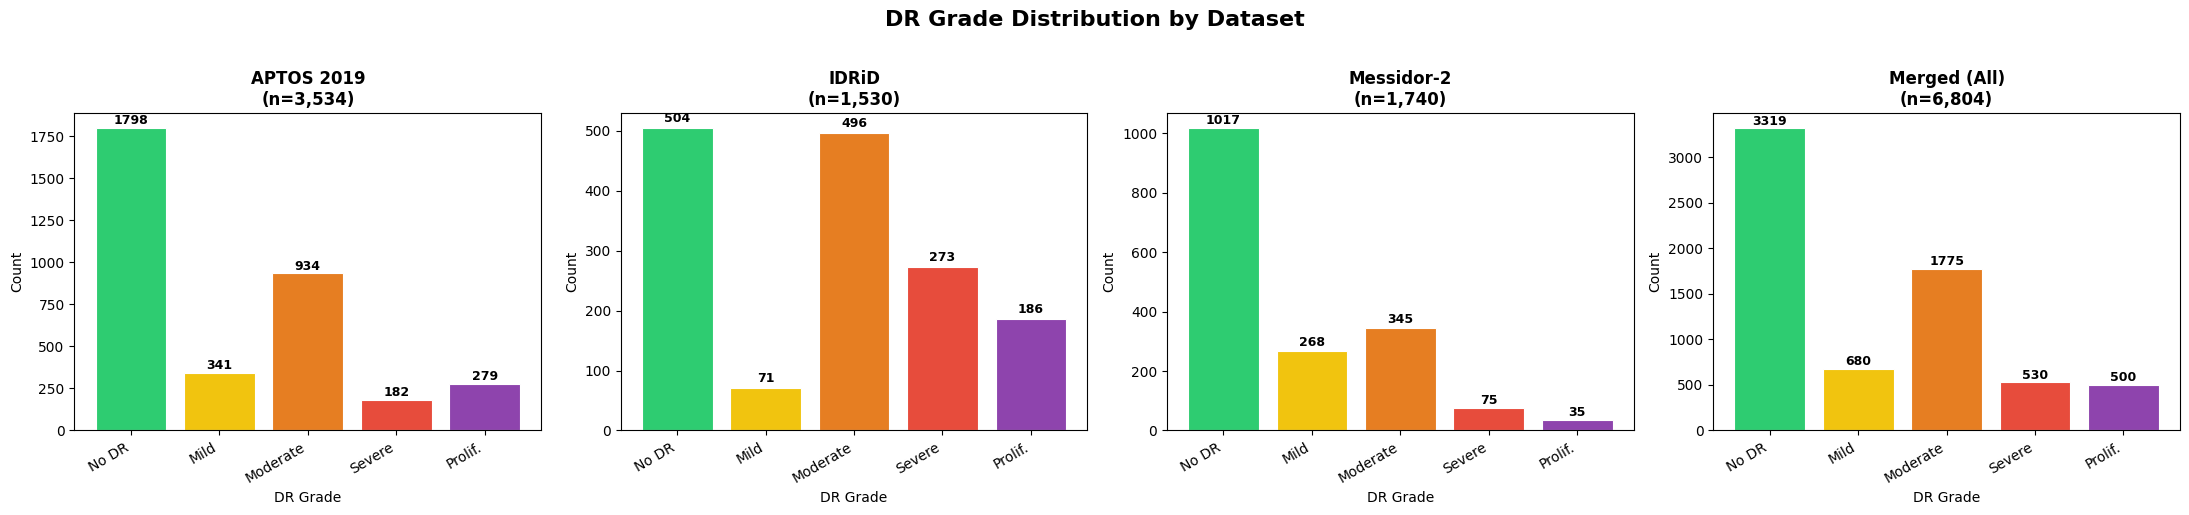

Saved → /sessions/vibrant-gifted-euler/mnt/DrMulti_Binary/figures/class_distribution_per_dataset.png


In [9]:
# ============================================================
# 7.1 Class distribution — per dataset and merged
# ============================================================
grade_names_short = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Prolif."}
palette = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("DR Grade Distribution by Dataset", fontsize=16, fontweight="bold", y=1.02)

datasets_to_plot = [
    ("APTOS 2019", "aptos2019"),
    ("IDRiD", "idrid"),
    ("Messidor-2", "messidor2"),
    ("Merged (All)", None),
]

for ax, (title, ds_key) in zip(axes, datasets_to_plot):
    if ds_key:
        sub = df_merged[df_merged["original_dataset"] == ds_key]
    else:
        sub = df_merged
    counts = sub["dr_grade"].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=palette, edgecolor="white", linewidth=0.8)
    ax.set_title(f"{title}\n(n={len(sub):,})", fontsize=12, fontweight="bold")
    ax.set_xlabel("DR Grade")
    ax.set_ylabel("Count")
    ax.set_xticks(range(5))
    ax.set_xticklabels([grade_names_short[g] for g in range(5)], rotation=30, ha="right")
    # Add value labels on bars
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(val), ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution_per_dataset.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'class_distribution_per_dataset.png'}")


### 7.2 Binary Label Distribution

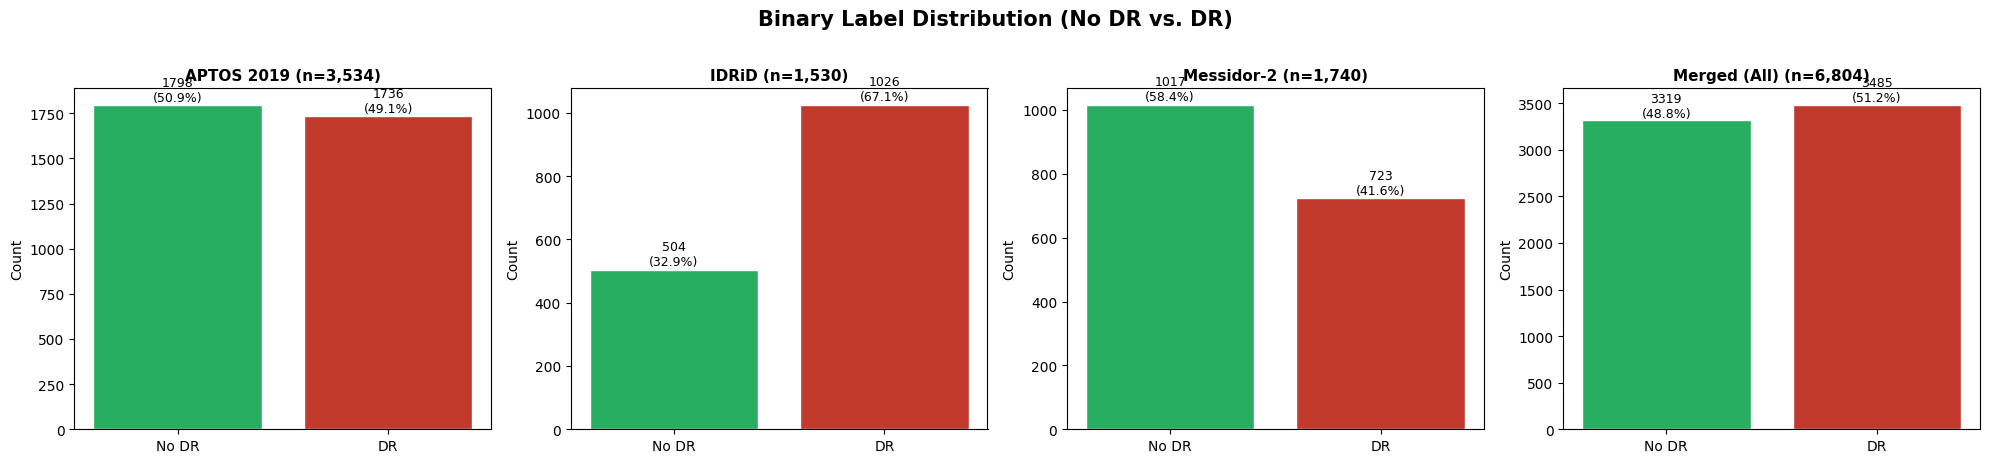

Saved → /sessions/vibrant-gifted-euler/mnt/DrMulti_Binary/figures/binary_distribution.png


In [10]:
# ============================================================
# 7.2 Binary label distribution
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.suptitle("Binary Label Distribution (No DR vs. DR)", fontsize=15, fontweight="bold", y=1.02)

binary_palette = ["#27ae60", "#c0392b"]

for ax, (title, ds_key) in zip(axes, datasets_to_plot):
    if ds_key:
        sub = df_merged[df_merged["original_dataset"] == ds_key]
    else:
        sub = df_merged
    counts = sub["binary_label"].value_counts().sort_index()
    bars = ax.bar(["No DR", "DR"], counts.values, color=binary_palette, edgecolor="white")
    ax.set_title(f"{title} (n={len(sub):,})", fontsize=11, fontweight="bold")
    ax.set_ylabel("Count")
    for bar, val in zip(bars, counts.values):
        pct = val / len(sub) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                f"{val}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "binary_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'binary_distribution.png'}")


### 7.3 Dataset Composition by Grade

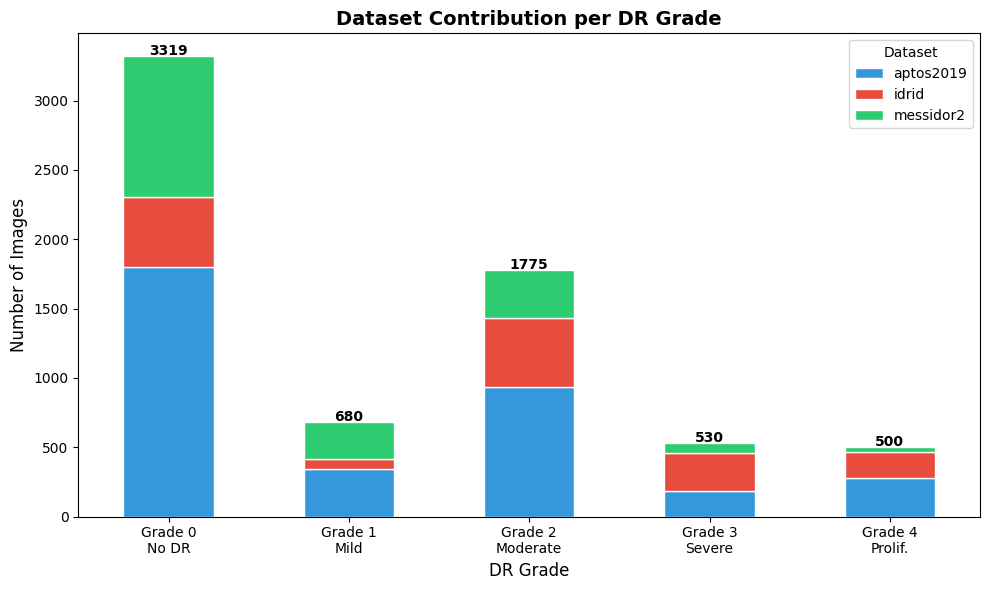

Saved → /sessions/vibrant-gifted-euler/mnt/DrMulti_Binary/figures/stacked_dataset_contribution.png


In [11]:
# ============================================================
# 7.3 Stacked bar — contribution of each dataset per grade
# ============================================================
cross = pd.crosstab(df_merged["dr_grade"], df_merged["original_dataset"])
cross = cross[["aptos2019", "idrid", "messidor2"]]  # order columns

fig, ax = plt.subplots(figsize=(10, 6))
cross.plot(kind="bar", stacked=True, ax=ax,
           color=["#3498db", "#e74c3c", "#2ecc71"], edgecolor="white")
ax.set_xlabel("DR Grade", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.set_title("Dataset Contribution per DR Grade", fontsize=14, fontweight="bold")
ax.set_xticklabels([f"Grade {g}\n{grade_names_short[g]}" for g in range(5)],
                    rotation=0, fontsize=10)
ax.legend(title="Dataset", fontsize=10)

# Add totals on top
for i, g in enumerate(range(5)):
    total = cross.loc[g].sum()
    ax.text(i, total + 10, str(total), ha="center", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / "stacked_dataset_contribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'stacked_dataset_contribution.png'}")


### 7.4 Sample Image Grid (3 Images per Grade)

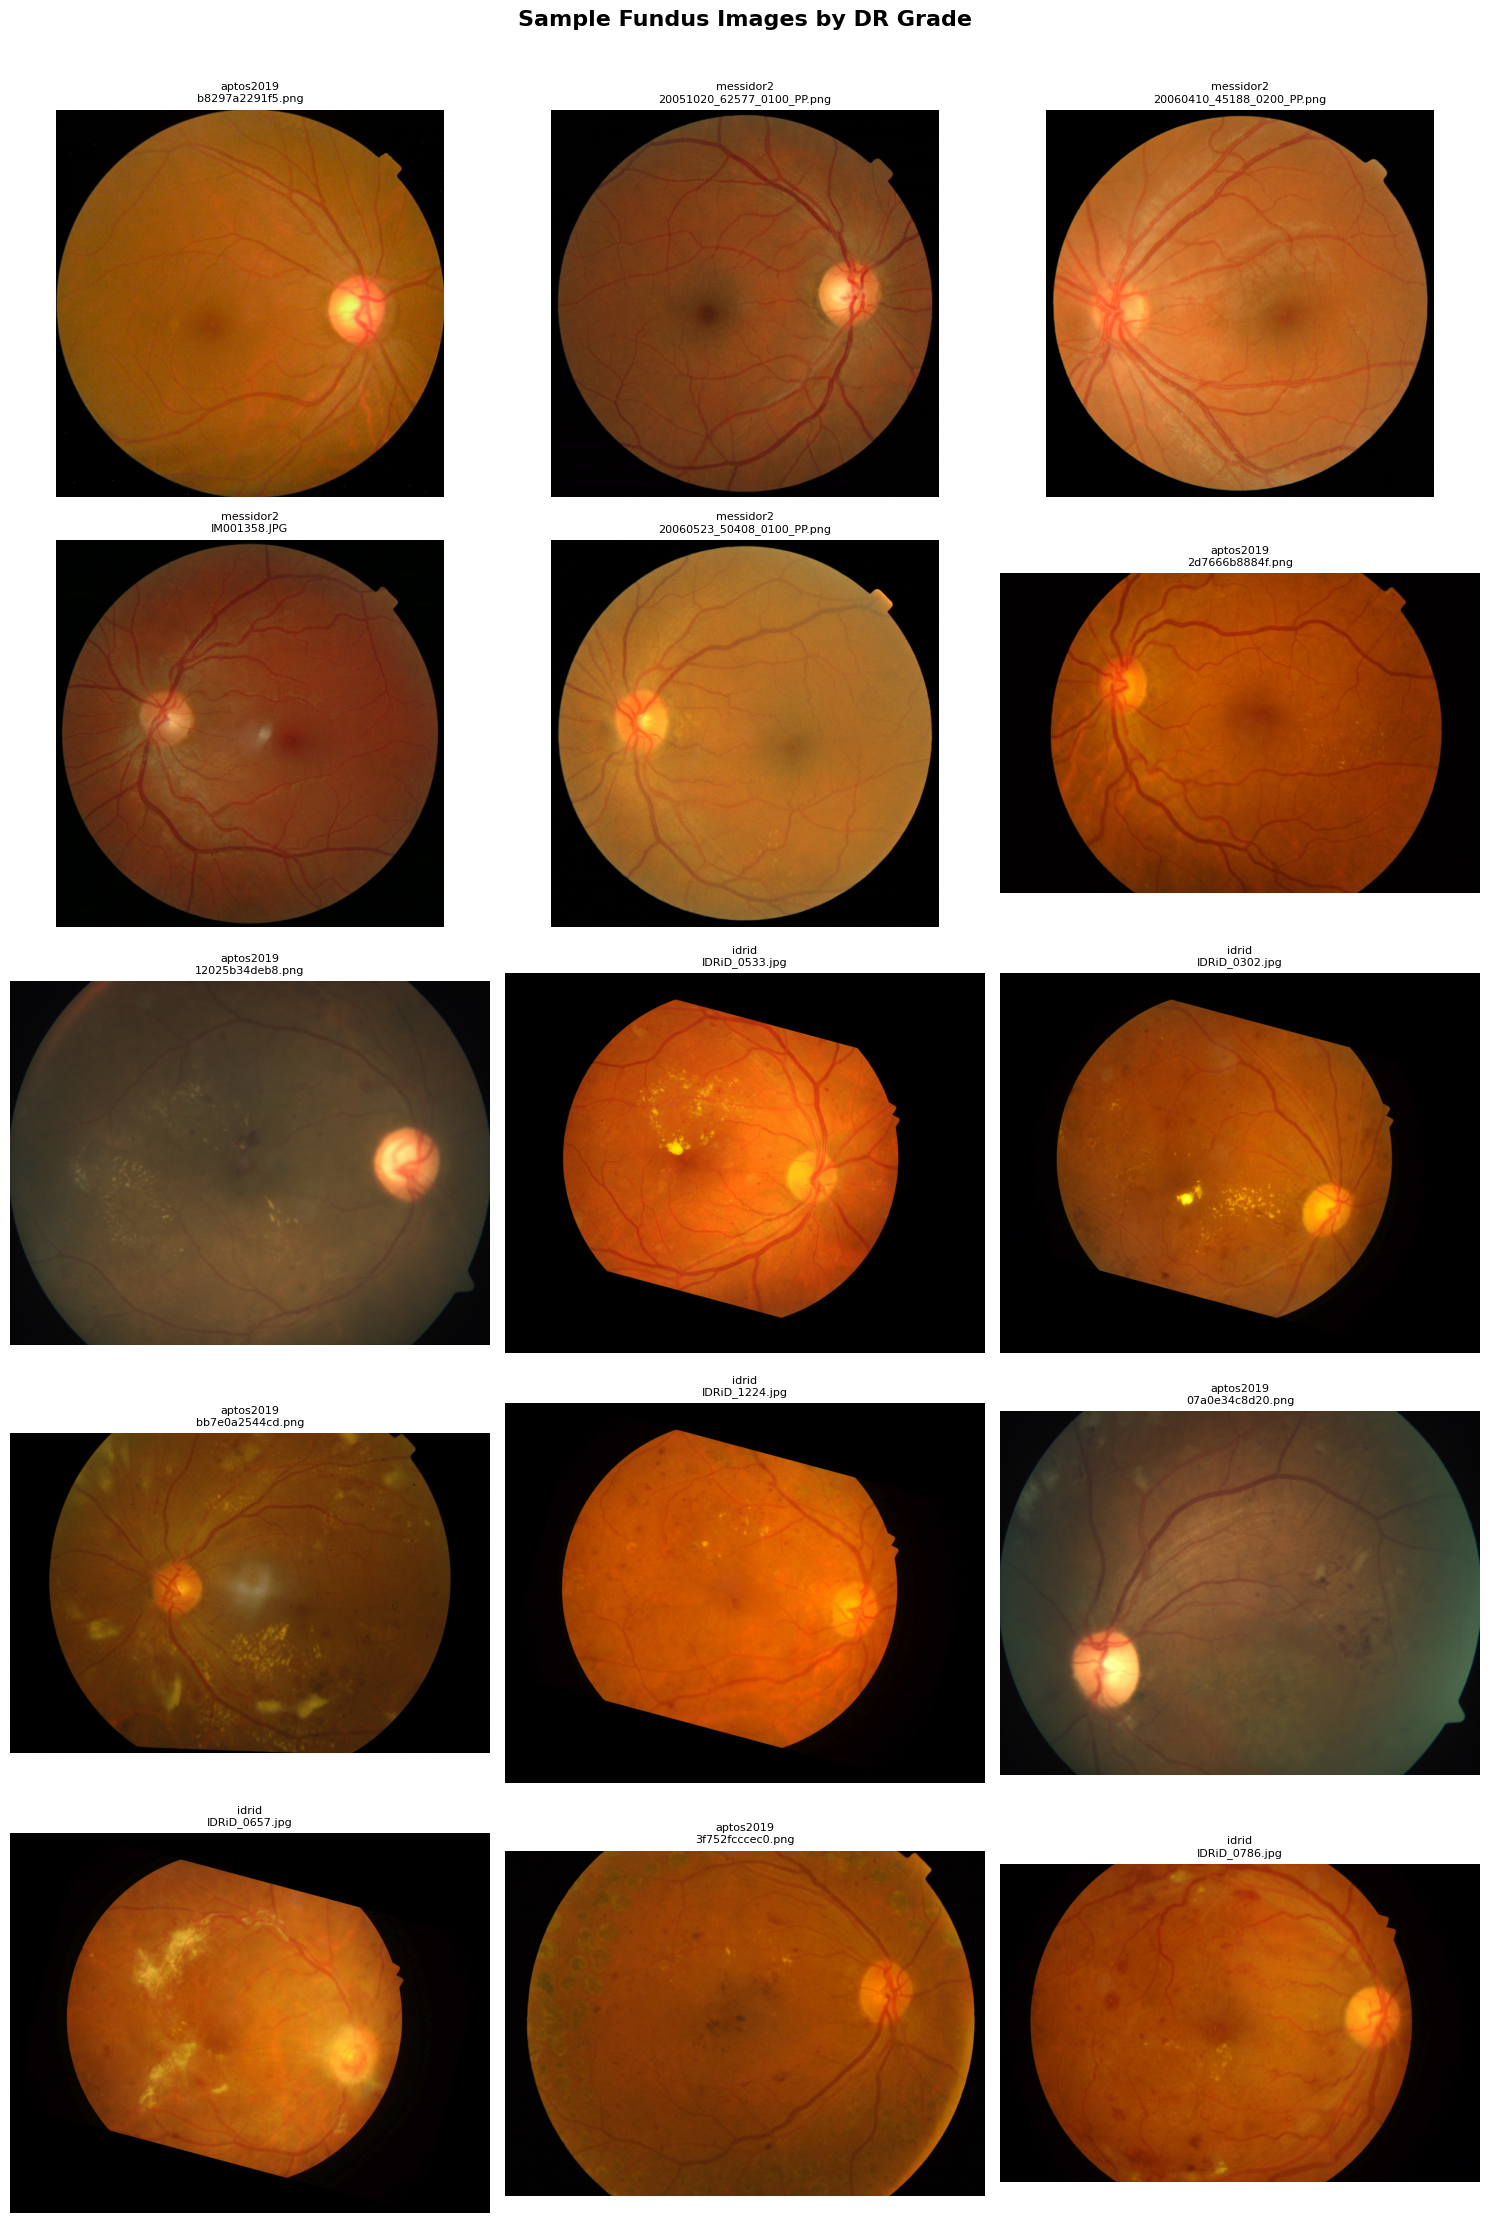

Saved → /sessions/vibrant-gifted-euler/mnt/DrMulti_Binary/figures/sample_image_grid.png


In [12]:
# ============================================================
# 7.4 Sample image grid — 3 random images per grade
# ============================================================
fig, axes = plt.subplots(5, 3, figsize=(15, 22))
fig.suptitle("Sample Fundus Images by DR Grade", fontsize=16, fontweight="bold", y=1.01)

for row_idx, grade in enumerate(range(5)):
    subset = df_merged[df_merged["dr_grade"] == grade]
    samples = subset.sample(n=min(3, len(subset)), random_state=SEED)

    for col_idx in range(3):
        ax = axes[row_idx, col_idx]
        if col_idx < len(samples):
            row = samples.iloc[col_idx]
            img = cv2.imread(str(ROOT / row["file_path"]))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
                ax.set_title(f"{row['original_dataset']}\n{Path(row['file_path']).name}",
                            fontsize=8)
            else:
                ax.text(0.5, 0.5, "Load Error", ha="center", va="center", transform=ax.transAxes)
        else:
            ax.axis("off")
            continue
        ax.axis("off")

    # Row label
    axes[row_idx, 0].set_ylabel(f"Grade {grade}\n{grade_names[grade]}",
                                  fontsize=11, fontweight="bold", rotation=0,
                                  labelpad=100, va="center")

plt.tight_layout()
plt.savefig(FIG_DIR / "sample_image_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'sample_image_grid.png'}")


### 7.5 Image Dimension Statistics

In [13]:
# ============================================================
# 7.5 Image dimension statistics (sample-based for speed)
# ============================================================
print("Sampling 500 images to compute dimension statistics...")
sample_df = df_merged.sample(n=min(500, len(df_merged)), random_state=SEED)

dims = []
for fp in tqdm(sample_df["file_path"].values, desc="Reading dimensions"):
    h, w, c = get_image_dimensions(str(ROOT / fp))
    if h > 0:
        dims.append({"height": h, "width": w, "channels": c,
                      "dataset": sample_df[sample_df["file_path"] == fp]["original_dataset"].values[0]})

df_dims = pd.DataFrame(dims)

print(f"\nDimension statistics (from {len(df_dims)} sampled images):")
print(f"  Height — min: {df_dims['height'].min()}, max: {df_dims['height'].max()}, "
      f"mean: {df_dims['height'].mean():.0f}, median: {df_dims['height'].median():.0f}")
print(f"  Width  — min: {df_dims['width'].min()}, max: {df_dims['width'].max()}, "
      f"mean: {df_dims['width'].mean():.0f}, median: {df_dims['width'].median():.0f}")

# Per-dataset stats
print("\nPer-dataset dimension summary:")
for ds in ["aptos2019", "idrid", "messidor2"]:
    sub = df_dims[df_dims["dataset"] == ds]
    if len(sub) > 0:
        print(f"  {ds:12s}: H={sub['height'].mean():.0f}±{sub['height'].std():.0f}, "
              f"W={sub['width'].mean():.0f}±{sub['width'].std():.0f}  (n={len(sub)})")


Sampling 500 images to compute dimension statistics...


Reading dimensions:   0%|          | 0/500 [00:00<?, ?it/s]

Reading dimensions:   0%|          | 2/500 [00:00<00:28, 17.32it/s]

Reading dimensions:   1%|          | 4/500 [00:00<00:36, 13.46it/s]

Reading dimensions:   1%|          | 6/500 [00:00<00:32, 15.19it/s]

...

Reading dimensions:  98%|█████████▊| 488/500 [00:16<00:00, 28.22it/s]

Reading dimensions:  99%|█████████▉| 494/500 [00:17<00:00, 33.53it/s]

Reading dimensions: 100%|█████████▉| 498/500 [00:17<00:00, 34.40it/s]

Reading dimensions: 100%|██████████| 500/500 [00:17<00:00, 28.92it/s]


Dimension statistics (from 500 sampled images):
  Height — min: 480, max: 3862, mean: 1655, median: 1536
  Width  — min: 512, max: 4880, mean: 2145, median: 2048

Per-dataset dimension summary:
  aptos2019   : H=1470±569, W=1928±905  (n=254)
  idrid       : H=3493±490, W=4665±286  (n=110)
  messidor2   : H=512±0, W=512±0  (n=136)


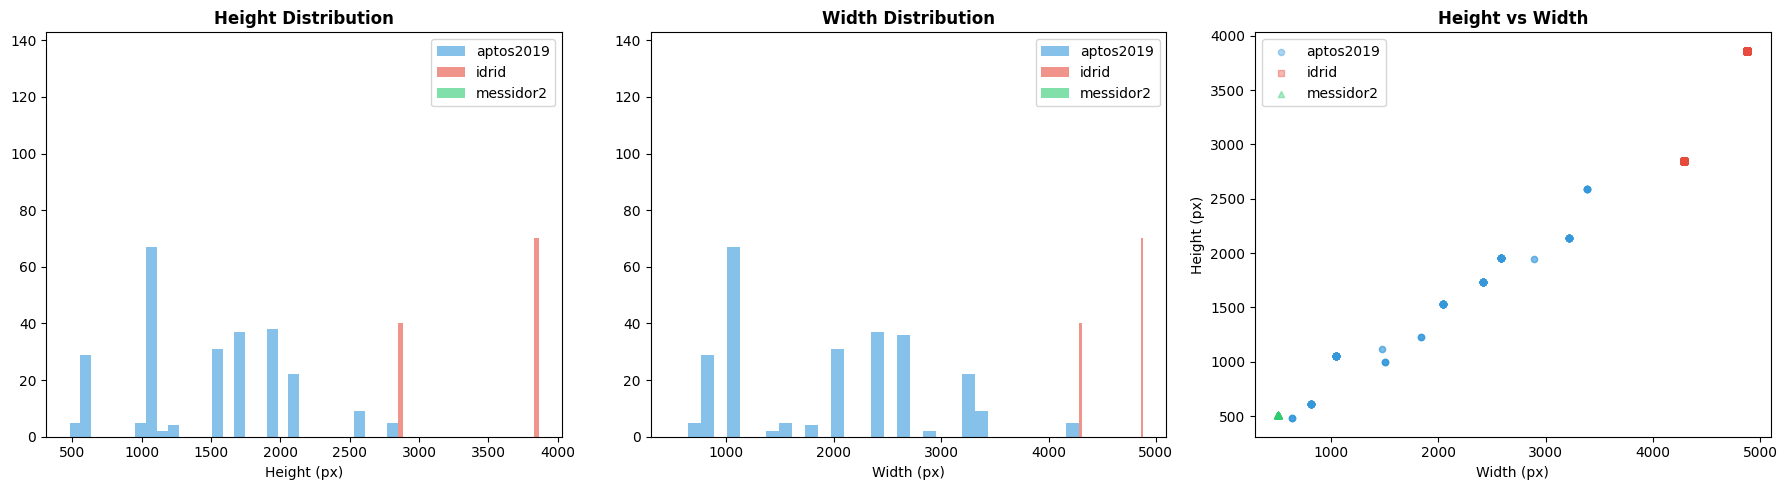

Saved → /sessions/vibrant-gifted-euler/mnt/DrMulti_Binary/figures/dimension_statistics.png


In [14]:
# ============================================================
# 7.5b Dimension distribution plots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Height distribution
for ds, color in [("aptos2019", "#3498db"), ("idrid", "#e74c3c"), ("messidor2", "#2ecc71")]:
    sub = df_dims[df_dims["dataset"] == ds]
    if len(sub) > 0:
        axes[0].hist(sub["height"], bins=30, alpha=0.6, label=ds, color=color)
axes[0].set_title("Height Distribution", fontweight="bold")
axes[0].set_xlabel("Height (px)")
axes[0].legend()

# Width distribution
for ds, color in [("aptos2019", "#3498db"), ("idrid", "#e74c3c"), ("messidor2", "#2ecc71")]:
    sub = df_dims[df_dims["dataset"] == ds]
    if len(sub) > 0:
        axes[1].hist(sub["width"], bins=30, alpha=0.6, label=ds, color=color)
axes[1].set_title("Width Distribution", fontweight="bold")
axes[1].set_xlabel("Width (px)")
axes[1].legend()

# Scatter: Height vs Width
for ds, color, marker in [("aptos2019", "#3498db", "o"), ("idrid", "#e74c3c", "s"), ("messidor2", "#2ecc71", "^")]:
    sub = df_dims[df_dims["dataset"] == ds]
    if len(sub) > 0:
        axes[2].scatter(sub["width"], sub["height"], alpha=0.4, label=ds,
                        color=color, marker=marker, s=20)
axes[2].set_title("Height vs Width", fontweight="bold")
axes[2].set_xlabel("Width (px)")
axes[2].set_ylabel("Height (px)")
axes[2].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "dimension_statistics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR / 'dimension_statistics.png'}")


## 8. Save Unified CSV

In [15]:
# ============================================================
# 8. Save the merged labels CSV
# ============================================================
# Final column order
output_cols = ["image_id", "original_dataset", "original_label",
               "dr_grade", "binary_label", "file_path", "image_hash"]
df_out = df_merged[output_cols].copy()

output_path = ROOT / CONFIG["output_csv"]
df_out.to_csv(output_path, index=False)

print(f"Saved unified CSV → {output_path}")
print(f"  Total rows  : {len(df_out):,}")
print(f"  Columns     : {list(df_out.columns)}")
print(f"  File size   : {os.path.getsize(output_path) / 1024:.1f} KB")

# Quick sanity check
df_check = pd.read_csv(output_path)
assert len(df_check) == len(df_out), "Row count mismatch after save!"
assert df_check["image_id"].is_unique, "image_id is not unique!"
print("\nSanity checks passed ✓")
print("\nFirst 5 rows:")
df_check.head()


Saved unified CSV → /sessions/vibrant-gifted-euler/mnt/DrMulti_Binary/merged_labels.csv
  Total rows  : 6,804
  Columns     : ['image_id', 'original_dataset', 'original_label', 'dr_grade', 'binary_label', 'file_path', 'image_hash']
  File size   : 1167.1 KB

Sanity checks passed ✓

First 5 rows:


,image_id,original_dataset,original_label,dr_grade,binary_label,file_path,image_hash
0,aptos_000c1434d8d7,aptos2019,2,2,1,/sessions/vibrant-gifted-euler/mnt/DrMulti_Bin...,e6155d8339d40577f97a5ce270aa81d1
1,aptos_001639a390f0,aptos2019,4,4,1,/sessions/vibrant-gifted-euler/mnt/DrMulti_Bin...,8f98205b18dfcc9111fe97037d9fe5ba
2,aptos_0024cdab0c1e,aptos2019,1,1,1,/sessions/vibrant-gifted-euler/mnt/DrMulti_Bin...,43e417a95e1259bc318493e399670cb8
3,aptos_002c21358ce6,aptos2019,0,0,0,/sessions/vibrant-gifted-euler/mnt/DrMulti_Bin...,f96db7f8fc458a804b0db13739bc976d
4,aptos_005b95c28852,aptos2019,0,0,0,/sessions/vibrant-gifted-euler/mnt/DrMulti_Bin...,17ecb0becd4bd280b3572ad31dce75b9


## 9. Summary & Next Steps

In [16]:
# ============================================================
# 9. Final summary
# ============================================================
print("=" * 70)
print("NOTEBOOK 00 — COMPLETE")
print("=" * 70)
print(f"\nMerged {len(df_out):,} unique fundus images from 3 datasets:")
print(f"  • APTOS 2019  : {(df_out['original_dataset']=='aptos2019').sum():,} images")
print(f"  • IDRiD        : {(df_out['original_dataset']=='idrid').sum():,} images")
print(f"  • Messidor-2   : {(df_out['original_dataset']=='messidor2').sum():,} images")
print(f"\nOutputs saved:")
print(f"  • {ROOT / CONFIG['output_csv']}")
print(f"  • {FIG_DIR}/ (EDA figures)")
print(f"\n→ Next: Notebook 01 — Preprocessing Pipeline")
print(f"  Will apply: Circle Crop → Ben Graham → CLAHE → Resize 384×384")


NOTEBOOK 00 — COMPLETE

Merged 6,804 unique fundus images from 3 datasets:
  • APTOS 2019  : 3,534 images
  • IDRiD        : 1,530 images
  • Messidor-2   : 1,740 images

Outputs saved:
  • /sessions/vibrant-gifted-euler/mnt/DrMulti_Binary/merged_labels.csv
  • /sessions/vibrant-gifted-euler/mnt/DrMulti_Binary/figures/ (EDA figures)

→ Next: Notebook 01 — Preprocessing Pipeline
  Will apply: Circle Crop → Ben Graham → CLAHE → Resize 384×384
